# 04. Feature Emergence With Linear Probes

This notebook is a new **experiment notebook** rather than a static report.

The goal is to estimate a **feature emergence curve** for the malicious-vs-benign classification signal:
- extract residual-stream activations from each layer
- train a separate linear probe at each layer
- measure how probe quality changes as depth increases

If the probe score rises sharply at a specific depth band, that is evidence that a linearly decodable classification feature becomes more explicit there.

This notebook uses the repo's existing prompt format and model-loading helpers from `scaled_validation.py`, but it adds a new per-layer probe workflow on top.

## Setup

The first code cell does the environment setup for the rest of the notebook:
- import plotting and tensor libraries
- locate the repository root from the current working directory
- add the repo root to `sys.path` so `scaled_validation.py` can be imported reliably
- define canonical paths for the dataset and output artifacts
- verify that `TransformerLens` is available before the heavier experiment steps begin


In [1]:
import json
import math
import sys
import time
from pathlib import Path


def find_project_root() -> Path:
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "artifacts").exists() and (candidate / "scaled_validation.py").exists():
            return candidate
        if (candidate / "mech-interp-circuit" / "artifacts").exists():
            return candidate / "mech-interp-circuit"
    raise FileNotFoundError("Could not find mech-interp-circuit project root from the current working directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from scaled_validation import (
    DEFAULT_MODEL_NAME,
    build_hooked_transformer,
    load_hf_model_and_tokenizer,
    make_prompt,
    require_transformer_lens,
)

sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="deep",
    rc={
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.facecolor": "#FCFCFC",
        "figure.facecolor": "white",
        "grid.color": "#D9DDE3",
        "grid.linewidth": 0.8,
        "axes.edgecolor": "#4A5568",
        "axes.labelcolor": "#1A202C",
        "xtick.color": "#2D3748",
        "ytick.color": "#2D3748",
        "axes.titleweight": "semibold",
    },
)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
torch.set_grad_enabled(False)


ARTIFACTS = PROJECT_ROOT / "artifacts"
DATASET_PATH = PROJECT_ROOT / "circuit_val_set.csv"
print("Project root:", PROJECT_ROOT)
print("Artifacts dir:", ARTIFACTS)
print("Dataset path:", DATASET_PATH)

require_transformer_lens()


Project root: /Users/rfetterman/DEV/mech-interp
Artifacts dir: /Users/rfetterman/DEV/mech-interp/artifacts
Dataset path: /Users/rfetterman/DEV/mech-interp/circuit_val_set.csv


## Step 1: Configure the experiment

The defaults below keep the notebook tractable on a single machine:
- use a balanced subset from `circuit_val_set.csv`
- cache only `hook_resid_pre` activations
- train one lightweight linear probe per layer

For a more stable curve, increase `MAX_SAMPLES_PER_LABEL` after the smoke test succeeds.


In [2]:
MODEL_NAME = DEFAULT_MODEL_NAME
TEMPLATE_NAME = "meta-llama/Llama-3.1-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else None
TORCH_DTYPE = "float16"

MAX_SAMPLES_PER_LABEL = 48
TEST_FRACTION = 0.25
RANDOM_SEED = 42
PROBE_MAX_ITER = 250
PROBE_L2 = 1e-2
SAVE_PREFIX = ARTIFACTS / "feature_emergence_linear_probe"

rng = np.random.default_rng(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## Step 2: Load and sample the validation set

We reuse the repo's balanced validation set and then downsample it for a first pass. The only required columns here are:
- `filename`
- `label`
- `content`


In [3]:
manifest = pd.read_csv(DATASET_PATH)
manifest = manifest[["filename", "label", "content", "primary_indicator", "used_char_len"]].copy()
manifest["label_id"] = manifest["label"].map({"benign": 0, "malicious": 1})

sampled_parts = []
for label, group in manifest.groupby("label", sort=True):
    take = min(MAX_SAMPLES_PER_LABEL, len(group))
    sampled_parts.append(group.sample(n=take, random_state=RANDOM_SEED))

sampled = pd.concat(sampled_parts, ignore_index=True)
sampled = sampled.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

sampled.groupby("label").agg(rows=("filename", "count"), mean_chars=("used_char_len", "mean"))


,rows,mean_chars
label,,
benign,48,4048.666667
malicious,48,515.479167


## Step 3: Load the model

This notebook follows the same two-stage model setup used elsewhere in the repo:
- load the Hugging Face model and tokenizer
- wrap it with `HookedTransformer` so layer activations can be cached cleanly


In [4]:
hf_model, tokenizer, resolved_device = load_hf_model_and_tokenizer(
    MODEL_NAME,
    device=DEVICE,
    torch_dtype=TORCH_DTYPE,
)
model = build_hooked_transformer(
    hf_model,
    tokenizer,
    device=resolved_device,
    torch_dtype=TORCH_DTYPE,
    template_name=TEMPLATE_NAME,
    first_n_layers=None,
    use_attn_result=False,
)
model.eval()

print("Device:", resolved_device)
print("Layers:", model.cfg.n_layers)
print("d_model:", model.cfg.d_model)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer
Device: mps
Layers: 32
d_model: 4096


Loading weights:   0%|          | 1/291 [00:00<00:52,  5.55it/s]

Loading weights:  17%|█▋        | 49/291 [00:00<00:01, 209.03it/s]

...

Loading weights:  70%|██████▉   | 203/291 [00:00<00:00, 268.71it/s]

Loading weights:  81%|████████▏ | 237/291 [00:00<00:00, 283.87it/s]

Loading weights:  91%|█████████▏| 266/291 [00:01<00:00, 276.13it/s]

Loading weights: 100%|██████████| 291/291 [00:01<00:00, 256.78it/s]

Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer
Device: cuda
Layers: 32
d_model: 4096


## Step 4: Helper functions for activation extraction and probe fitting

The probe is deliberately simple:
- use the final token position in the prompt
- read `hook_resid_pre` for every layer
- fit a binary linear model with L2 regularization

This is a useful first-pass emergence curve, but it is not the only possible definition. Later variants could compare `resid_pre`, `resid_mid`, `resid_post`, attention outputs, or MLP outputs.


In [15]:
def stratified_split_indices(labels, test_fraction=0.25, seed=42):
    labels = np.asarray(labels)
    rng = np.random.default_rng(seed)
    train_idx = []
    test_idx = []
    for label in sorted(np.unique(labels)):
        label_idx = np.flatnonzero(labels == label)
        rng.shuffle(label_idx)
        n_test = max(1, int(round(len(label_idx) * test_fraction)))
        if len(label_idx) - n_test < 1:
            n_test = max(1, len(label_idx) - 1)
        test_idx.extend(label_idx[:n_test].tolist())
        train_idx.extend(label_idx[n_test:].tolist())
    return np.array(sorted(train_idx)), np.array(sorted(test_idx))


def binary_auroc(y_true, y_score):
    y_true = np.asarray(y_true).astype(np.int64)
    y_score = np.asarray(y_score, dtype=np.float64)
    pos = y_true == 1
    neg = y_true == 0
    n_pos = int(pos.sum())
    n_neg = int(neg.sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    order = np.argsort(y_score)
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, len(y_score) + 1)
    rank_sum_pos = ranks[pos].sum()
    u_stat = rank_sum_pos - (n_pos * (n_pos + 1) / 2.0)
    return float(u_stat / (n_pos * n_neg))


def standardize_train_test(x_train, x_test, eps=1e-6):
    mean = x_train.mean(axis=0, keepdims=True)
    std = x_train.std(axis=0, keepdims=True)
    std = np.where(std < eps, 1.0, std)
    return (x_train - mean) / std, (x_test - mean) / std


def fit_linear_probe(x_train, y_train, x_test, *, max_iter=250, l2=1e-2):
    x_train_t = torch.tensor(x_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    x_test_t = torch.tensor(x_test, dtype=torch.float32)

    probe = torch.nn.Linear(x_train_t.shape[1], 1)
    optimizer = torch.optim.LBFGS(
        probe.parameters(),
        lr=1.0,
        max_iter=max_iter,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        logits = probe(x_train_t)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, y_train_t)
        penalty = 0.5 * l2 * probe.weight.pow(2).sum()
        total = loss + penalty
        total.backward()
        return total

    with torch.enable_grad():
        optimizer.step(closure)

    with torch.no_grad():
        train_logits = probe(x_train_t).squeeze(1).cpu().numpy()
        test_logits = probe(x_test_t).squeeze(1).cpu().numpy()
    return train_logits, test_logits, probe


def collect_resid_pre_activations(model, rows: pd.DataFrame):
    prompts = rows["content"].map(make_prompt).tolist()
    label_ids = rows["label_id"].to_numpy(dtype=np.int64)
    n_layers = model.cfg.n_layers
    d_model = model.cfg.d_model
    activations = np.zeros((len(prompts), n_layers, d_model), dtype=np.float32)
    final_logit_diff = np.zeros(len(prompts), dtype=np.float32)

    allow_token_id = tokenizer.encode(" ALLOW", add_special_tokens=False)[0]
    block_token_id = tokenizer.encode(" BLOCK", add_special_tokens=False)[0]

    start = time.time()
    for idx, prompt in enumerate(prompts):
        tokens = model.to_tokens(prompt)
        logits, cache = model.run_with_cache(
            tokens,
            return_type="logits",
            names_filter=lambda name: name.endswith("hook_resid_pre"),
        )
        for layer in range(n_layers):
            hook_name = f"blocks.{layer}.hook_resid_pre"
            activations[idx, layer] = cache[hook_name][0, -1, :].detach().float().cpu().numpy()
        final_logit_diff[idx] = float((logits[0, -1, block_token_id] - logits[0, -1, allow_token_id]).item())
        if (idx + 1) % 10 == 0 or idx == len(prompts) - 1:
            elapsed = time.time() - start
            print(f"Processed {idx + 1}/{len(prompts)} prompts in {elapsed:.1f}s")
        del logits
        del cache

    return activations, label_ids, final_logit_diff


def evaluate_probe_curve(activations, labels, *, test_fraction=0.25, seed=42, max_iter=250, l2=1e-2):
    train_idx, test_idx = stratified_split_indices(labels, test_fraction=test_fraction, seed=seed)
    rows = []
    trained_probes = {}

    for layer in range(activations.shape[1]):
        x_layer = activations[:, layer, :]
        x_train = x_layer[train_idx]
        x_test = x_layer[test_idx]
        y_train = labels[train_idx]
        y_test = labels[test_idx]

        x_train, x_test = standardize_train_test(x_train, x_test)
        train_logits, test_logits, probe = fit_linear_probe(
            x_train,
            y_train,
            x_test,
            max_iter=max_iter,
            l2=l2,
        )

        train_pred = (train_logits > 0).astype(np.int64)
        test_pred = (test_logits > 0).astype(np.int64)
        rows.append(
            {
                "layer": layer,
                "train_accuracy": float((train_pred == y_train).mean()),
                "test_accuracy": float((test_pred == y_test).mean()),
                "train_auroc": binary_auroc(y_train, train_logits),
                "test_auroc": binary_auroc(y_test, test_logits),
                "mean_train_logit": float(train_logits.mean()),
                "mean_test_logit": float(test_logits.mean()),
                "train_rows": int(len(train_idx)),
                "test_rows": int(len(test_idx)),
            }
        )
        trained_probes[layer] = probe

    curve = pd.DataFrame(rows)
    return curve, train_idx, test_idx, trained_probes


## Step 5: Collect per-layer activations

This is the expensive step. Each prompt is run once through the full model and the notebook keeps only the final-position `resid_pre` vector for each layer.


In [16]:
activations, labels, model_logit_diff = collect_resid_pre_activations(model, sampled)
print("Activation tensor shape:", activations.shape)
print("Mean final model logit diff:", float(model_logit_diff.mean()))


RuntimeError: MPS backend out of memory (MPS allocated: 30.16 GiB, other allocations: 736.00 KiB, max allowed: 30.19 GiB). Tried to allocate 8.00 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

Processed 20/96 prompts in 2.1s


Processed 30/96 prompts in 3.0s


Processed 40/96 prompts in 4.0s


Processed 50/96 prompts in 4.6s


Processed 60/96 prompts in 5.3s


Processed 70/96 prompts in 6.0s


Processed 80/96 prompts in 6.7s


Processed 90/96 prompts in 7.3s


Processed 96/96 prompts in 7.8s
Activation tensor shape: (96, 32, 4096)
Mean final model logit diff: 1.5335897207260132


## Step 6: Train one linear probe per layer

Each point on the emergence curve answers a narrow question:

> If we look only at the residual stream just before layer `L`, how well can a linear classifier already separate benign from malicious scripts?


In [17]:
curve_df, train_idx, test_idx, trained_probes = evaluate_probe_curve(
    activations,
    labels,
    test_fraction=TEST_FRACTION,
    seed=RANDOM_SEED,
    max_iter=PROBE_MAX_ITER,
    l2=PROBE_L2,
)

curve_df.head()


NameError: name 'activations' is not defined

## Step 7: Plot the feature emergence curve

The cleanest summary is usually test AUROC by layer. Accuracy is also shown because it is easier to interpret quickly, but AUROC is usually the more stable curve for a small balanced sample.


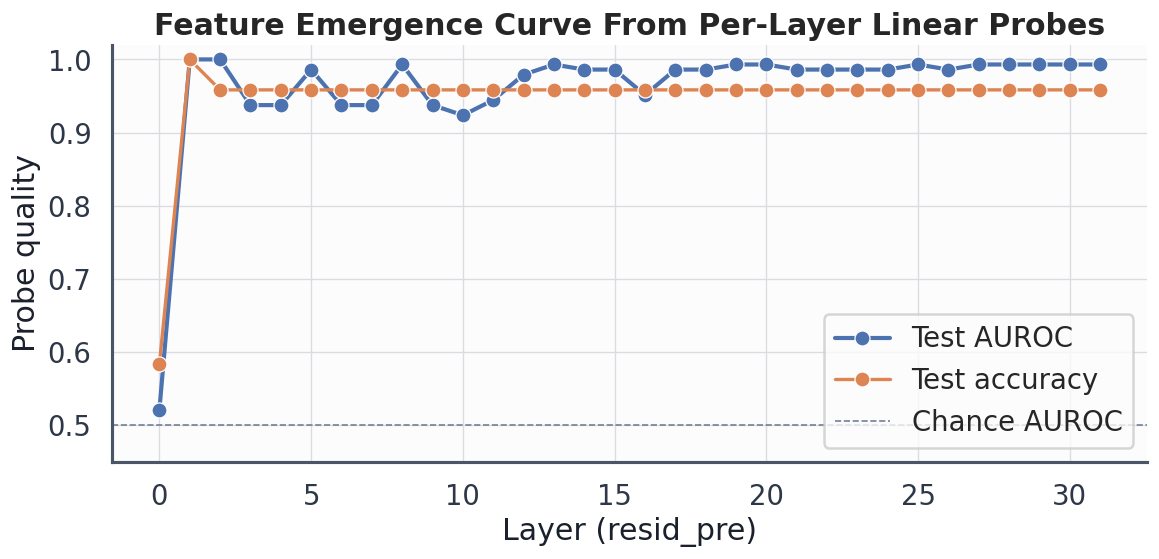

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=curve_df, x="layer", y="test_auroc", marker="o", linewidth=2.5, label="Test AUROC", ax=ax)
sns.lineplot(data=curve_df, x="layer", y="test_accuracy", marker="o", linewidth=2.0, label="Test accuracy", ax=ax)
ax.axhline(0.5, color="#718096", linestyle="--", linewidth=1, label="Chance AUROC")
ax.set_ylim(0.45, 1.02)
ax.set_title("Feature Emergence Curve From Per-Layer Linear Probes")
ax.set_xlabel("Layer (resid_pre)")
ax.set_ylabel("Probe quality")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


NameError: name 'curve_df' is not defined

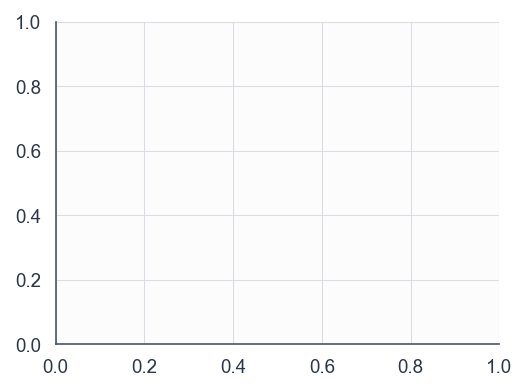

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

  # Optional: if you have SciencePlots installed, uncomment these two lines.
#import scienceplots
  # plt.style.use(["science", "nature", "no-latex"])

  # Publication-style defaults without extra dependencies.
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "grid.linewidth": 0.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
  })

fig, ax = plt.subplots(figsize=(3.4, 2.5), constrained_layout=True)

# Colorblind-safe, print-friendly palette
auroc_color = "#1b5e20"   # dark green
acc_color = "#37474f"     # dark blue-gray
chance_color = "#9e9e9e"

ax.plot(
    curve_df["layer"],
    curve_df["test_auroc"],
    label="Test AUROC",
    color=auroc_color,
    linewidth=1.8,
    marker="o",
    markersize=3.8,
    markerfacecolor="white",
    markeredgewidth=0.9,
)

ax.plot(
    curve_df["layer"],
    curve_df["test_accuracy"],
    label="Test accuracy",
    color=acc_color,
    linewidth=1.5,
    linestyle="--",
    marker="s",
    markersize=3.4,
    markerfacecolor="white",
    markeredgewidth=0.9,
)

ax.axhline(
    0.5,
    color=chance_color,
    linestyle=":",
    linewidth=1.0,
    label="Chance",
)

# Highlight best layer by AUROC
best_idx = curve_df["test_auroc"].idxmax()
best_layer = int(curve_df.loc[best_idx, "layer"])
best_auroc = float(curve_df.loc[best_idx, "test_auroc"])

ax.scatter(
    [best_layer],
    [best_auroc],
    s=36,
    color=auroc_color,
    zorder=5,
)
ax.annotate(
    f"Best layer = {best_layer}",
    xy=(best_layer, best_auroc),
    xytext=(6, -14),
    textcoords="offset points",
    fontsize=8,
)

ax.set_xlabel("Layer (resid_pre)")
ax.set_ylabel("Probe performance")
ax.set_ylim(0.45, 1.02)
ax.set_xlim(curve_df["layer"].min() - 0.5, curve_df["layer"].max() + 0.5)
ax.grid(axis="y", alpha=0.35)
ax.legend(frameon=False, loc="lower right", handlelength=2.4)

# Optional title for notebook viewing; often omitted in papers.
# ax.set_title("Per-layer linear probe performance")

paper_dir = Path("../artifacts")
paper_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(paper_dir / "feature_emergence_linear_probe_paper.pdf", bbox_inches="tight")
fig.savefig(paper_dir / "feature_emergence_linear_probe_paper.png", bbox_inches="tight")
plt.show()

## Step 8: Inspect the strongest layer

This does not prove mechanistic causality by itself, but it does tell you where a linearly decodable feature is strongest under this probe definition.


In [9]:
best_row = curve_df.sort_values(["test_auroc", "test_accuracy"], ascending=False).iloc[0]
best_layer = int(best_row["layer"])
print(best_row.to_string())

layer_table = curve_df.sort_values("test_auroc", ascending=False).reset_index(drop=True)
layer_table.head(10)


layer                1.000000
train_accuracy       1.000000
test_accuracy        1.000000
train_auroc          1.000000
test_auroc           1.000000
mean_train_logit    -0.383502
mean_test_logit      0.219890
train_rows          72.000000
test_rows           24.000000


,layer,train_accuracy,test_accuracy,train_auroc,test_auroc,mean_train_logit,mean_test_logit,train_rows,test_rows
0,1,1.0,1.000000,1.0,1.000000,-0.383502,0.219890,72,24
1,2,1.0,0.958333,1.0,1.000000,-0.540326,-0.570777,72,24
2,13,1.0,0.958333,1.0,0.993056,-0.005216,-1.607200,72,24
3,8,1.0,0.958333,1.0,0.993056,-0.126012,-1.001707,72,24
4,30,1.0,0.958333,1.0,0.993056,0.318324,-0.834358,72,24
5,31,1.0,0.958333,1.0,0.993056,0.016186,-1.474770,72,24
6,20,1.0,0.958333,1.0,0.993056,0.330832,-0.861568,72,24
7,19,1.0,0.958333,1.0,0.993056,0.529434,-0.712440,72,24
8,25,1.0,0.958333,1.0,0.993056,0.360833,-0.589270,72,24
9,27,1.0,0.958333,1.0,0.993056,-0.003374,-1.159475,72,24


## Step 9: Save the results

The CSV is useful for comparing repeated runs with different sample sizes or alternative probe definitions.


In [10]:
SAVE_PREFIX.parent.mkdir(parents=True, exist_ok=True)
curve_path = SAVE_PREFIX.with_suffix(".csv")
plot_path = SAVE_PREFIX.with_suffix(".png")
meta_path = SAVE_PREFIX.with_name(SAVE_PREFIX.name + "_metadata.json")

curve_df.to_csv(curve_path, index=False)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=curve_df, x="layer", y="test_auroc", marker="o", linewidth=2.5, label="Test AUROC", ax=ax)
sns.lineplot(data=curve_df, x="layer", y="test_accuracy", marker="o", linewidth=2.0, label="Test accuracy", ax=ax)
ax.axhline(0.5, color="#718096", linestyle="--", linewidth=1)
ax.set_ylim(0.45, 1.02)
ax.set_title("Feature Emergence Curve From Per-Layer Linear Probes")
ax.set_xlabel("Layer (resid_pre)")
ax.set_ylabel("Probe quality")
plt.tight_layout()
fig.savefig(plot_path, bbox_inches="tight")
plt.close(fig)

metadata = {
    "model_name": MODEL_NAME,
    "template_name": TEMPLATE_NAME,
    "device": resolved_device,
    "torch_dtype": TORCH_DTYPE,
    "max_samples_per_label": MAX_SAMPLES_PER_LABEL,
    "test_fraction": TEST_FRACTION,
    "random_seed": RANDOM_SEED,
    "probe_max_iter": PROBE_MAX_ITER,
    "probe_l2": PROBE_L2,
    "rows_total": int(len(sampled)),
    "train_rows": int(len(train_idx)),
    "test_rows": int(len(test_idx)),
    "best_layer": best_layer,
    "best_test_auroc": float(best_row["test_auroc"]),
    "best_test_accuracy": float(best_row["test_accuracy"]),
    "curve_csv": str(curve_path),
    "curve_png": str(plot_path),
}
meta_path.write_text(json.dumps(metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8")

print("Saved:")
print(" -", curve_path)
print(" -", plot_path)
print(" -", meta_path)


Saved:
 - /home/ryan/mech-interp-circuit-validation/artifacts/feature_emergence_linear_probe.csv
 - /home/ryan/mech-interp-circuit-validation/artifacts/feature_emergence_linear_probe.png
 - /home/ryan/mech-interp-circuit-validation/artifacts/feature_emergence_linear_probe_metadata.json


## Step 10: Useful follow-up variants

If this first curve looks promising, the next sensible extensions are:
- compare `resid_pre` versus `resid_mid` and `resid_post`
- fit probes on matched benign/malicious pairs only
- restrict to a single indicator family to test whether emergence is family-specific
- compare the probe curve with the repo's ablation and patching summaries to see whether linear decodability and causal importance peak in the same depth range
